In [36]:
from tensorflow.keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=20000)

In [37]:
len(imdb.get_word_index())

88584

In [38]:
max([max(sequence) for sequence in train_data])

19999

In [ ]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[0]])
decoded_review

In [ ]:
word_index

In [ ]:
reverse_word_index

In [7]:
test_data.shape

(25000,)

In [8]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
words = ["running", "studying", "smiling", "communication"]
stemmed_words = [stemmer.stem(word) for word in words]
print(stemmed_words)

['run', 'studi', 'smile', 'commun']


In [9]:
import nltk
nltk.download('wordnet')


[nltk_data] Downloading package wordnet to C:\Users\Nasir
[nltk_data]     Hussain\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
lemmatizer = WordNetLemmatizer()
words = ["running", "better", "studies", "was"]
lemmas = [
    lemmatizer.lemmatize("running", pos=wordnet.VERB),
    lemmatizer.lemmatize("better", pos=wordnet.ADJ),
    lemmatizer.lemmatize("studies", pos=wordnet.NOUN),
    lemmatizer.lemmatize("was", pos=wordnet.VERB)
]
print(lemmas)

['run', 'good', 'study', 'be']


In [11]:
print(train_data[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [12]:
len(train_data[0]), len(train_data[111]), len(train_data[128])

(218, 274, 533)

In [40]:
import numpy as np
def vectorize_sequences(sequences, dimension=20000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
      for j in sequence:
        results[i, j] = 1.
    return results


In [14]:
np.zeros((10,10))


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [41]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [42]:
x_train[0].size

20000

In [17]:
len(train_data[0])


218

In [18]:
np.unique(np.array(train_data[0])).size

120

In [43]:
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [58]:
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [59]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [60]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [61]:
history = model.fit(partial_x_train,
            partial_y_train,
            epochs=10,
            batch_size=512,
            validation_data=(x_val, y_val))

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.6890 - loss: 0.5806 - val_accuracy: 0.8859 - val_loss: 0.2915
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9424 - loss: 0.1815 - val_accuracy: 0.8909 - val_loss: 0.2839
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9792 - loss: 0.0832 - val_accuracy: 0.8811 - val_loss: 0.3453
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9903 - loss: 0.0456 - val_accuracy: 0.8849 - val_loss: 0.3813
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9980 - loss: 0.0196 - val_accuracy: 0.8787 - val_loss: 0.4415
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9996 - loss: 0.0095 - val_accuracy: 0.8773 - val_loss: 0.4926
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9997 - loss: 0.0059 - val_accuracy: 0.8777 - val_loss: 0.5239
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9997 - loss: 0.0038 - val_accuracy: 0.8764 - v

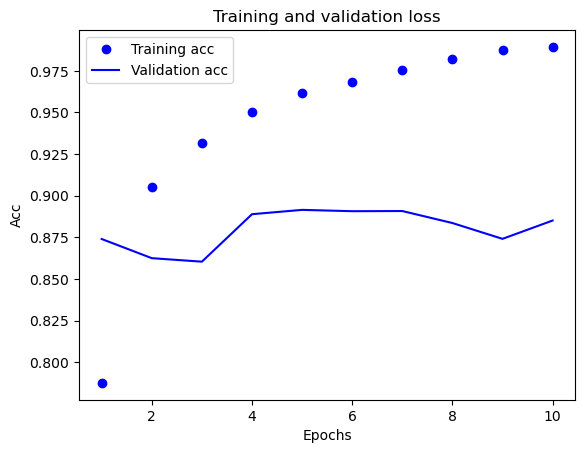

In [49]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["accuracy"]
val_loss_values = history_dict["val_accuracy"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training acc")
plt.plot(epochs, val_loss_values, "b", label="Validation acc")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Acc")
plt.legend()
plt.show()

In [25]:
model = keras.Sequential([
            layers.Dense(16, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
 loss="binary_crossentropy",
 metrics=["accuracy"])


In [26]:
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7424 - loss: 0.5824
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8947 - loss: 0.3072
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9213 - loss: 0.2306
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9304 - loss: 0.1945
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8787 - loss: 0.2926


In [27]:
y_pred = model.predict(x_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [32]:
y_pred = [1 if pred>=0.5 else 0 for pred in y_pred]

In [33]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, classification_report

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.85      0.92      0.88     12500
         1.0       0.91      0.84      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000

